In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
import ast
df['job_skills'] = df['job_skills'].apply( lambda job_skills : ast.literal_eval(job_skills ) if pd.notna(job_skills) else job_skills )

In [5]:
df_ge_de = df[
       (df['job_title_short'] == 'Data Engineer') &
       (df['job_country'] == 'Germany')
       ].copy()

df_ge_de = df_ge_de.dropna( subset = ['salary_year_avg'])
df_ge_de.sample(10)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
745711,Data Engineer,Data Architect and Archiving Consultant (f/m/...,"Wernau, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-03-29 21:13:32,False,False,Germany,year,165000.0,NaN,Bosch Group,"[spark, sap]","{'analyst_tools': ['sap'], 'libraries': ['spar..."
506805,Data Engineer,Data Engineering Manager - Customer squad,"Berlin, Germany",via Ai-Jobs.net,Contractor,False,Germany,2023-04-24 11:15:58,False,False,Germany,year,147500.0,NaN,Back Market,"[python, dynamodb, aws, gcp, spark, terraform]","{'cloud': ['aws', 'gcp'], 'databases': ['dynam..."
547988,Data Engineer,Data Engineer (f/m/x),"Berlin, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-07-07 19:13:07,False,False,Germany,year,97444.0,NaN,AUTO1 Group,"[sql, python, postgresql, aws, redshift, pyspa...","{'cloud': ['aws', 'redshift'], 'databases': ['..."
188183,Data Engineer,Research Engineer - Laser Material Processing ...,"Renningen, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-01-25 15:59:33,False,False,Germany,year,200000.0,NaN,Bosch Group,"[python, spark, github]","{'libraries': ['spark'], 'other': ['github'], ..."
391155,Data Engineer,ETL Entwickler (m/w/d) - Datastage,"Frankfurt, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-01-19 19:05:29,True,False,Germany,year,56700.0,NaN,ALTEN,[sql],{'programming': ['sql']}
700199,Data Engineer,"Working Student, Geospatial Data Engineer","Berlin, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-04-01 03:16:37,False,False,Germany,year,147500.0,NaN,Planet Labs Inc.,"[python, sql, react, gdpr, git]","{'libraries': ['react', 'gdpr'], 'other': ['gi..."
537865,Data Engineer,(Senior/Lead) Data Engineer (m/f/d),"Munich, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-03-08 19:14:34,False,False,Germany,year,147500.0,NaN,Devoteam,"[sql, aws, gcp, spark, sap]","{'analyst_tools': ['sap'], 'cloud': ['aws', 'g..."
682655,Data Engineer,Work Student (m/f/d) Data Engineering,"Göppingen, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-01-18 10:22:52,False,False,Germany,year,98283.0,NaN,TeamViewer,"[sql, java, python, aws, gcp, spark, airflow, ...","{'cloud': ['aws', 'gcp'], 'libraries': ['spark..."
257651,Data Engineer,Junior Operations Specialist for Azure Cloud B...,"Stuttgart, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-03-29 08:13:41,False,False,Germany,year,56700.0,NaN,Bosch Group,"[bash, python, azure, spark, git, bitbucket]","{'cloud': ['azure'], 'libraries': ['spark'], '..."
122140,Data Engineer,Product Owner (m/f/d) Data Engineering,"Munich, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-02-28 08:21:22,False,False,Germany,year,147500.0,NaN,Jochen Schweizer mydays Group,"[databricks, kafka, git, jenkins, jira]","{'async': ['jira'], 'cloud': ['databricks'], '..."


In [27]:
df_exploded = df_ge_de.explode('job_skills')
df_group = df_exploded.groupby('job_skills')['salary_year_avg'].agg ([  'count','median'])


df1 = df_group.sort_values(by = 'median' , ascending= False).head(10)

df2 = df_group.sort_values(by = 'count', ascending= False).head(10).sort_values(by = 'median' , ascending= False).head(10)

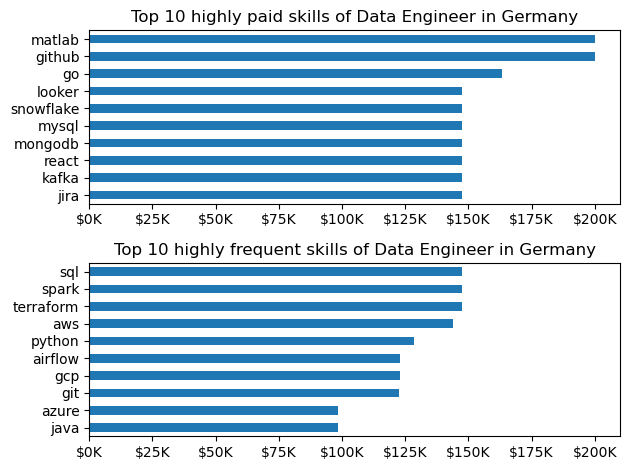

In [36]:
fig , ax = plt.subplots(2,1)

df1[::-1].plot(kind='barh', y = 'median'  , ax = ax[0], legend = False)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _ : f'${int(x/1000)}K'))
ax[0].set_title("Top 10 highly paid skills of Data Engineer in Germany")
ax[0].set_xlabel('')
ax[0].set_ylabel('')

df2[::-1].plot(kind='barh', y = 'median'  , ax = ax[1], legend = False)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _ : f'${int(x/1000)}K'))
ax[1].set_title("Top 10 highly frequent skills of Data Engineer in Germany")
ax[1].set_xlabel('')
ax[1].set_ylabel('')

ax[1].set_xlim(ax[0].get_xlim())

fig.tight_layout()

In [37]:
import seaborn as sns

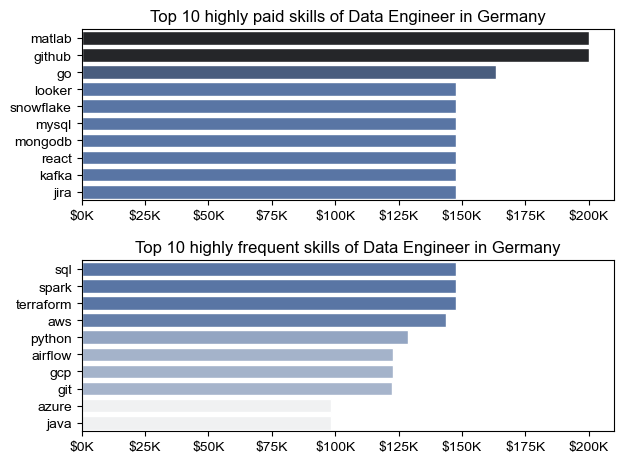

In [44]:
fig , ax = plt.subplots(2,1)

sns.set_theme(style='ticks')

sns.barplot(data = df1 , x= 'median', y= df1.index, ax= ax[0], hue='median',palette= 'dark:b_r' )
ax[0].legend().remove()
#df1[::-1].plot(kind='barh', y = 'median'  , ax = ax[0], legend = False)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _ : f'${int(x/1000)}K'))
ax[0].set_title("Top 10 highly paid skills of Data Engineer in Germany")
ax[0].set_xlabel('')
ax[0].set_ylabel('')

sns.barplot(data = df2 , x= 'median', y= df2.index, ax= ax[1], hue='median',palette= 'light:b' )
ax[1].legend().remove()
#df2[::-1].plot(kind='barh', y = 'median'  , ax = ax[1], legend = False)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _ : f'${int(x/1000)}K'))
ax[1].set_title("Top 10 highly frequent skills of Data Engineer in Germany")
ax[1].set_xlabel('')
ax[1].set_ylabel('')

ax[1].set_xlim(ax[0].get_xlim())

fig.tight_layout()